# Supplementary Figure 1 — Tracking reward-based decision making, task
acquisition and engagement utilizing a home-cage touchscreen
Source: `_source_archive/by_figure/Fig1/04_LocationBasedShifting.ipynb`
(same notebook as Fig 1 -- confirmed by user), "STATS EXTRACTION: Results
Section 1" section, STAT 1 (pre-block-change accuracy), STAT 3/4 (P(break)
after win/loss, P(break) at block transition vs. within block -- both
labeled Supp Fig 1G in that section).

Panel legends below are copied verbatim from the submitted/bioRxiv
manuscript (`2026.06.30.734629v1.full.pdf`, Supplementary Figures section).
Panels a-b (apparatus photo / acquisition schematic) are illustrations, not
data-derived -- placeholder cells only. Panel c (p(high-prob choice) aligned
to a block transition) reuses `src/behavior_metrics/reversal_alignment.py`
(built for Fig 2/3) applied to Fig 1's own WhereTask data, with a simple
per-session transitions_df built the same way Fig 3's notebook builds its
own (every block change, no cued/uncued split -- this task has none).
Panel e is a new joint (previous-outcome x block-status) breakdown of the
same break-taking data panel d already uses, combined via a new additive
function in `supp_fig1_breaks.py` (`p_break_by_outcome_and_transition`).

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from IPython.display import SVG, display

from src.io.load_snapshots import load_config, load_snapshot
from src.behavior_metrics import supp_fig1_breaks as breaks
from src.behavior_metrics import reversal_alignment as revalign
from src.plotting.style import apply_style
from src.plotting import supp_fig1 as plotting

config = load_config()
apply_style(config)
fig1_cfg = config["fig1"]
cfg = config["suppfig1"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "SuppFig1")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {}


def show(path):
    display(SVG(path))

## Load data (same snapshot as Fig 1)

In [2]:
df = load_snapshot(config, fig1_cfg["input_files"]["where_task_100_0"])
print(f"Loaded {len(df):,} trials from {df['Session_ID'].nunique()} sessions, "
      f"{df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

Loaded 79,606 trials from 363 sessions, 10 animals


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/io/load_snapshots.py:36: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


## Panel a
**Manuscript legend:** *"Picture of task screen holder device (left) and
while attached to the home-cage (right) with a platform for marmosets to
position in front of the screen and a port that provides sweetened liquid
rewards"*

**Status: not applicable.** This is a photograph of the physical apparatus,
not a data-derived panel -- no analysis to run.

## Panel b
**Manuscript legend:** *"Schematic representation of acquisition
sequences. “Touch behavior” rewards any touch behavior within the
black circle with decreasing size to enhance touch precision. Following
successful touch behavior, marmosets interact with “shifting
locations” where the smallest stimuli is moved to all possible
positions on the screen and rewarded for all touches within stimuli."*

**Status: not applicable.** This is an illustrative schematic of the
shaping procedure, not a data-derived panel -- no analysis to run.

## Panel c
**Manuscript legend:** *"Probability of selecting the high probability
choice (‘high-prob choice’) at each trial position for each
individual marmoset (colored lines) or the average (black line)."*

Not previously built. Structurally the same "individual + average, aligned
to a block transition" panel as Fig 1 panel b / Fig 2-3 panel b, applied
here to Fig 1's own VDT/WhereTask data. A simple transitions_df is built
below covering every block change in every session (no cued/uncued split
needed -- the visual discrimination task has a single transition type),
the same way Fig 3's notebook builds its own transitions_df from
BlockCount -- here from Fig 1's `Block` column instead (confirmed
equivalent to `BlockCount` in this dataset).

In [3]:
trans_records = []
for session_id, session_df in df.sort_values("Trial").groupby("Session_ID"):
    animal = session_df["Animal_Name"].iloc[0]
    blocks = sorted(session_df["Block"].unique())
    for i in range(1, len(blocks)):
        trans_records.append({
            "session_id": session_id, "animal": animal,
            "to_block": blocks[i],
        })
trans_df = pd.DataFrame(trans_records)
print(f"Total block transitions: {len(trans_df)}")
manifest["n_block_transitions"] = int(len(trans_df))

Total block transitions: 2039


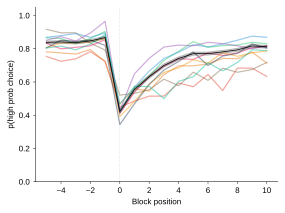

    position      mean       sem     n
0         -5  0.838191  0.008258  1990
1         -4  0.841206  0.008195  1990
2         -3  0.836683  0.008289  1990
3         -2  0.847236  0.008067  1990
4         -1  0.867839  0.007594  1990
5          0  0.421775  0.010939  2039
6          1  0.554519  0.011018  2036
7          2  0.631657  0.010714  2028
8          3  0.699308  0.010200  2022
9          4  0.741679  0.009758  2013
10         5  0.770304  0.009392  2007
11         6  0.770771  0.009406  1998
12         7  0.781124  0.009267  1992
13         8  0.793260  0.009085  1988
14         9  0.816944  0.008686  1983
15        10  0.811646  0.008800  1975


In [4]:
aligned_df = revalign.accuracy_by_position_relative_to_transition(
    df, trans_df, "Outcome",
    cfg["pre_block_change_window"], cfg["block_transition_window_after"],
    block_col="Block",
)
overall_summary = revalign.summarize_by_position(aligned_df)
per_animal_summary = revalign.summarize_by_position(aligned_df, group_cols=("animal",))
per_animal_summary = per_animal_summary.rename(columns={"mean": "accuracy"})

plotting.plot_engaged_across_transitions(
    per_animal_summary, overall_summary, config, os.path.join(FIG_DIR, "engaged_across_transitions.svg")
)
show(os.path.join(FIG_DIR, "engaged_across_transitions.svg"))
print(overall_summary)
manifest["engaged_across_transitions"] = {
    str(row["position"]): {"mean": float(row["mean"]), "sem": float(row["sem"]), "n": int(row["n"])}
    for _, row in overall_summary.iterrows()
}

## Panel d
**Manuscript legend:** *"Probability of a disengagement (p(break))
following a block transition or within the same block (left) or after a
rewarded or unrewarded outcome (right) across all individual marmosets
(dots)."*

Already built (`p_break_transition_vs_within.svg`, `p_break_win_vs_loss.svg`)
-- verified against this legend text (category order/colors match:
Block Transition/Same Block on the left, and Unrewarded/Rewarded --
i.e. Loss/Win -- on the right).

Pre-block-change accuracy: 0.835 +/- 0.003 (n=12300 trials, 10 animals), Wilcoxon vs chance p=1.9531e-03


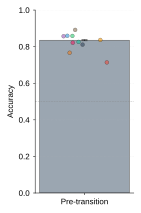

In [5]:
pre_result = breaks.pre_block_change_accuracy(df, cfg["pre_block_change_window"])
print(f"Pre-block-change accuracy: {pre_result['mean']:.3f} +/- {pre_result['sem']:.3f} "
      f"(n={pre_result['n_trials']} trials, {pre_result['n_animals']} animals), "
      f"Wilcoxon vs chance p={pre_result['wilcoxon_p_vs_chance_per_animal']:.4e}")

plotting.plot_pre_block_change_accuracy(pre_result, config, os.path.join(FIG_DIR, "pre_block_change_accuracy.svg"))
show(os.path.join(FIG_DIR, "pre_block_change_accuracy.svg"))
# Manifest keeps only the original stat fields -- "per_animal_accuracy" is a
# plotting-only addition (see supp_fig1_breaks.pre_block_change_accuracy)
# and is deliberately excluded so the values manifest is unaffected.
manifest["pre_block_change_accuracy"] = {
    k: pre_result[k] for k in
    ["n_trials", "n_animals", "mean", "sem", "wilcoxon_p_vs_chance_per_animal"]
}

P(break|Win)=0.084, P(break|Loss)=0.187, Wilcoxon p=1.9531e-03 (n=10 animals)


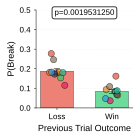

P(break|Transition)=0.156, P(break|Same block)=0.108, Wilcoxon p=1.9531e-03 (n=10 animals)


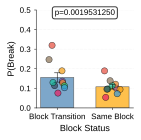

In [6]:
df_iti_clean = breaks.prepare_break_analysis_df(df, fig1_cfg["bout_iti_threshold"])

win_loss_result = breaks.p_break_by_prev_outcome(df_iti_clean)
print(f"P(break|Win)={win_loss_result['p_break_win']:.3f}, P(break|Loss)={win_loss_result['p_break_loss']:.3f}, "
      f"Wilcoxon p={win_loss_result['wilcoxon_p']:.4e} (n={win_loss_result['n_animals']} animals)")
# Category order/colors match the source's alphabetically-groupby-sorted
# category order in Break_Analysis_PerAnimal_WHERE_100-0.svg (Loss, Win).
plotting.plot_p_break_comparison(
    [
        {"label": "Loss", "color": "#e74c3c",
         "mean": win_loss_result["p_break_loss"], "sem": win_loss_result["p_break_loss_sem"],
         "per_animal": win_loss_result["loss_per_animal"]},
        {"label": "Win", "color": "#2ecc71",
         "mean": win_loss_result["p_break_win"], "sem": win_loss_result["p_break_win_sem"],
         "per_animal": win_loss_result["win_per_animal"]},
    ],
    xlabel="Previous Trial Outcome", p_value=win_loss_result["wilcoxon_p"],
    config=config, out_path=os.path.join(FIG_DIR, "p_break_win_vs_loss.svg"),
)
show(os.path.join(FIG_DIR, "p_break_win_vs_loss.svg"))
# Manifest keeps only the original stat fields -- the *_sem and *_per_animal
# fields are plotting-only additions (see supp_fig1_breaks.p_break_by_prev_outcome)
# and are deliberately excluded so the values manifest is unaffected.
manifest["p_break_win_vs_loss"] = {
    k: win_loss_result[k] for k in
    ["n_trials", "n_animals", "p_break_win", "p_break_loss", "wilcoxon_p"]
}

transition_result = breaks.p_break_by_block_transition(df_iti_clean)
print(f"P(break|Transition)={transition_result['p_break_transition']:.3f}, "
      f"P(break|Same block)={transition_result['p_break_same_block']:.3f}, "
      f"Wilcoxon p={transition_result['wilcoxon_p']:.4e} (n={transition_result['n_animals']} animals)")
# Category order/colors match the source cell (Block Transition, Same Block).
plotting.plot_p_break_comparison(
    [
        {"label": "Block Transition", "color": "steelblue",
         "mean": transition_result["p_break_transition"], "sem": transition_result["p_break_transition_sem"],
         "per_animal": transition_result["transition_per_animal"]},
        {"label": "Same Block", "color": "orange",
         "mean": transition_result["p_break_same_block"], "sem": transition_result["p_break_same_block_sem"],
         "per_animal": transition_result["same_block_per_animal"]},
    ],
    xlabel="Block Status", p_value=transition_result["wilcoxon_p"],
    config=config, out_path=os.path.join(FIG_DIR, "p_break_transition_vs_within.svg"),
)
show(os.path.join(FIG_DIR, "p_break_transition_vs_within.svg"))
# Manifest keeps only the original stat fields (see note above).
manifest["p_break_transition_vs_within"] = {
    k: transition_result[k] for k in
    ["n_trials", "n_animals", "p_break_transition", "p_break_same_block", "wilcoxon_p"]
}

## Panel e
**Manuscript legend:** *"Heatmap representing the relationship between the
previous outcome and block status on the probability of taking a break"*

Not previously built. Combines the same two conditions panel d already
splits marginally (previous outcome; block status) into one joint 2x2
breakdown, via a new additive function
(`supp_fig1_breaks.p_break_by_outcome_and_transition`) that does not modify
the existing marginal functions panel d already uses/reports.

rewarded_transition: p(break)=0.124 +/- 0.024 (n=10 animals)
rewarded_same_block: p(break)=0.082 +/- 0.011 (n=10 animals)
unrewarded_transition: p(break)=0.298 +/- 0.027 (n=10 animals)
unrewarded_same_block: p(break)=0.184 +/- 0.014 (n=10 animals)


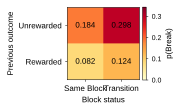

In [7]:
joint_result = breaks.p_break_by_outcome_and_transition(df_iti_clean)
for cell_key, cell_stats in joint_result["cells"].items():
    print(f"{cell_key}: p(break)={cell_stats['mean']:.3f} +/- {cell_stats['sem']:.3f} "
          f"(n={cell_stats['n_animals']} animals)")

plotting.plot_p_break_heatmap(joint_result, config, os.path.join(FIG_DIR, "p_break_outcome_by_transition_heatmap.svg"))
show(os.path.join(FIG_DIR, "p_break_outcome_by_transition_heatmap.svg"))
manifest["p_break_by_outcome_and_transition"] = joint_result["cells"]
manifest["p_break_by_outcome_and_transition"]["n_animals_common"] = joint_result["n_animals_common"]

## Values manifest

In [8]:
manifest_path = os.path.join(MANIFEST_DIR, "SuppFig1.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")
print(json.dumps(manifest, indent=2, default=str))


Saved values manifest: ../outputs/values_manifests/SuppFig1.json
{
  "n_trials": 79606,
  "n_sessions": 363,
  "n_animals": 10,
  "n_block_transitions": 2039,
  "engaged_across_transitions": {
    "-5.0": {
      "mean": 0.8381909547738694,
      "sem": 0.008257631359582388,
      "n": 1990
    },
    "-4.0": {
      "mean": 0.8412060301507538,
      "sem": 0.008195034762927633,
      "n": 1990
    },
    "-3.0": {
      "mean": 0.8366834170854272,
      "sem": 0.008288545606154274,
      "n": 1990
    },
    "-2.0": {
      "mean": 0.8472361809045226,
      "sem": 0.008066685198451768,
      "n": 1990
    },
    "-1.0": {
      "mean": 0.8678391959798994,
      "sem": 0.007593702436376993,
      "n": 1990
    },
    "0.0": {
      "mean": 0.4217753800882786,
      "sem": 0.010939231485594421,
      "n": 2039
    },
    "1.0": {
      "mean": 0.5545186640471512,
      "sem": 0.011017692166396344,
      "n": 2036
    },
    "2.0": {
      "mean": 0.6316568047337278,
      "sem": 0.0107